# Masterclass 1

So, for me mainly as theoretical physicist this data analysis magic is kinda scary, but I want to challenge me and try to figure this out.

Here:

$$
P_{ee}=1.
$$

The goal is to build the event model

$$
{}^8\mathrm{B}\ \nu_e \rightarrow \nu e\ \mathrm{scattering}\rightarrow e^-_{\rm recoil},
$$

then generate pseudo-data and fit the normalization of the ${}^8\mathrm{B}$ solar-neutrino flux:

$$
\Phi_{^8\mathrm{B}}\rightarrow \alpha_B\Phi_{^8\mathrm{B}}.
$$


## Main outputs

The notebook produces:

1. ${}^8\mathrm{B}$ neutrino spectrum;
2. SK-like recoil-electron spectrum $dN/dT_e$;
3. total expected event count above a chosen threshold;
4. pseudo-data in the same recoil-energy bins;
5. best-fit $\hat\alpha_B$ and a one-dimensional interval from $q(\alpha_B)$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 1. Inputs

As I understand, we have experimental data. In this masterclass it is these three tables:

- `solar_fluxes.csv` — solar-neutrino fluxes;
- `energy_spectra.csv` — normalized energy spectra;
- `nu_electron_recoil_cross_sections.csv` — differential recoil cross sections.


In [2]:
BASE = "https://neutrinohit.github.io/neutrinophysics/solar-neutrino-masterclass"

fluxes = pd.read_csv(f"{BASE}/data/masterclass1/solar_fluxes.csv")
spectra = pd.read_csv(f"{BASE}/data/masterclass1/energy_spectra.csv")
xs = pd.read_csv(f"{BASE}/data/masterclass1/nu_electron_recoil_cross_sections.csv")

print("fluxes columns:", list(fluxes.columns))
print("spectra columns:", list(spectra.columns))
print("cross-section columns:", list(xs.columns))

display(fluxes.head())
display(spectra.head())
display(xs.head())

fluxes columns: ['source', 'flux_cm2_s', 'kind', 'endpoint_MeV', 'line_energies_MeV', 'line_weights', 'group', 'comment']
spectra columns: ['source', 'E_MeV', 'spectrum_per_MeV', 'kind']
cross-section columns: ['E_MeV', 'T_e_MeV', 'T_max_MeV', 'dsigma_nue_cm2_per_MeV', 'dsigma_nux_cm2_per_MeV']


,source,flux_cm2_s,kind,endpoint_MeV,line_energies_MeV,line_weights,group,comment
0,pp,5.980000e+10,continuum,0.42,NaN,NaN,pp-chain,dominant low-energy flux
1,pep,1.440000e+08,line,NaN,1.44,1.0,pp-chain,monoenergetic line
2,hep,7.980000e+03,continuum,18.80,NaN,NaN,pp-chain,rare high-energy tail
3,Be7,4.930000e+09,line,NaN,0.384;0.862,0.103;0.897,pp-chain,electron-capture lines
4,B8,5.460000e+06,continuum,16.00,NaN,NaN,pp-chain,high-energy branch


,source,E_MeV,spectrum_per_MeV,kind
0,pp,0.02,0.147128,continuum
1,pp,0.04,0.531132,continuum
2,pp,0.06,1.072564,continuum
3,pp,0.08,1.700800,continuum
4,pp,0.10,2.354049,continuum


,E_MeV,T_e_MeV,T_max_MeV,dsigma_nue_cm2_per_MeV,dsigma_nux_cm2_per_MeV
0,0.05,0.0,0.008183,1.013464e-44,2.166263e-45
1,0.05,0.1,0.008183,0.000000e+00,0.000000e+00
2,0.05,0.2,0.008183,0.000000e+00,0.000000e+00
3,0.05,0.3,0.008183,0.000000e+00,0.000000e+00
4,0.05,0.4,0.008183,0.000000e+00,0.000000e+00


## 2. ${}^8\mathrm{B}$ flux and spectrum

The full ${}^8\mathrm{B}$ flux is

$$
\Phi_{^8\mathrm{B}}.
$$

The normalized spectral shape is

$$
f_{^8\mathrm{B}}(E_\nu).
$$

Then

$$
\frac{d\Phi_{^8\mathrm{B}}}{dE_\nu}
=
\Phi_{^8\mathrm{B}}f_{^8\mathrm{B}}(E_\nu).
$$

Code below extracts $^8B$ flux, multiply it by spectra, checks if it's normalized.

In [3]:
phi_b8 = float(
    fluxes.loc[fluxes["source"] == "B8", "flux_cm2_s"].iloc[0]
)

b8 = spectra.loc[spectra["source"] == "B8"].copy()
b8 = b8.sort_values("E_MeV")

norm_b8 = np.trapezoid(b8["spectrum_per_MeV"], b8["E_MeV"])

print(f"Phi_B8 = {phi_b8:.6e} cm^-2 s^-1")
print(f"Integral of B8 spectrum = {norm_b8:.12f}")

Phi_B8 = 5.460000e+06 cm^-2 s^-1
Integral of B8 spectrum = 1.000000000000


## 3. Plot the ${}^8\mathrm{B}$ neutrino spectrum

First we plot the normalized shape

$$
f_{^8\mathrm{B}}(E_\nu),
$$

then the differential flux

$$
\frac{d\Phi_{^8\mathrm{B}}}{dE_\nu}.
$$


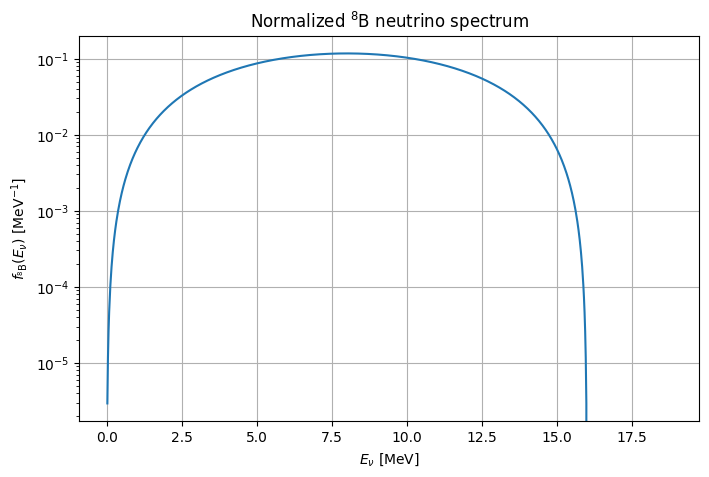

In [4]:
fig, ax = plt.subplots()

ax.plot(b8["E_MeV"], b8["spectrum_per_MeV"])
ax.set_yscale("log")
ax.set_xlabel(r"$E_\nu$ [MeV]")
ax.set_ylabel(r"$f_{^8\mathrm{B}}(E_\nu)$ [MeV$^{-1}$]")
ax.set_title(r"Normalized $^8\mathrm{B}$ neutrino spectrum")

plt.show()

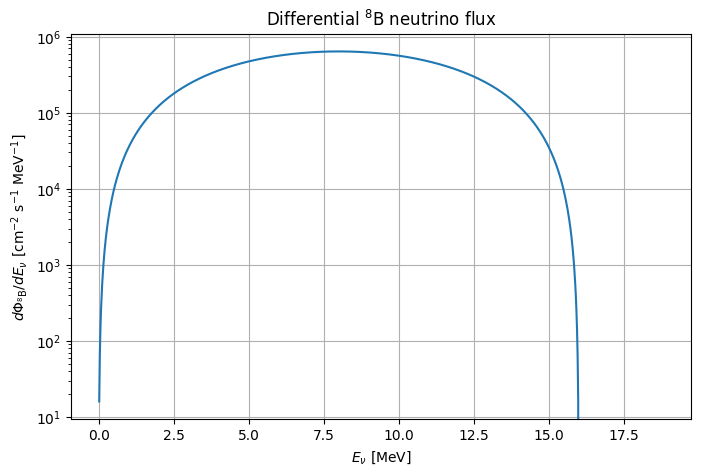

In [5]:
b8 = b8.assign(dphi_dE=phi_b8 * b8["spectrum_per_MeV"])

fig, ax = plt.subplots()

ax.plot(b8["E_MeV"], b8["dphi_dE"])
ax.set_yscale("log")
ax.set_xlabel(r"$E_\nu$ [MeV]")
ax.set_ylabel(r"$d\Phi_{^8\mathrm{B}}/dE_\nu$ [cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
ax.set_title(r"Differential $^8\mathrm{B}$ neutrino flux")

plt.show()

## 4. Detector exposure and number of target electrons

For water,

$$
N_e = 10N_A\frac{M_{\rm water}}{18~\mathrm{g}}.
$$

The factor 10 appears because one molecule of water, $H_2O$, has 10 electrons.

We use the example exposure:

$$
M_{\rm water}=100~\mathrm{kton},
\qquad
T_{\rm live}=1~\mathrm{year}.
$$


In [6]:
N_A = 6.02214076e23
seconds_per_year = 365.25 * 24 * 3600

mass_g = 100.0e9          # 100 kton water = 100e9 g
T_live = seconds_per_year # one year in seconds

N_e = 10.0 * N_A * mass_g / 18.0

print(f"N_e = {N_e:.6e}")
print(f"T_live = {T_live:.6e} s")

N_e = 3.345634e+34
T_live = 3.155760e+07 s


## 5. Build the event template $m_j$

For recoil-energy bin $j$,

$$
\mu_j(\alpha_B)
=
\alpha_B N_eT_{\rm live}
\int_{T_j}^{T_{j+1}}dT_e
\int dE_\nu\,
\Phi_{^8\mathrm{B}}f_{^8\mathrm{B}}(E_\nu)
\frac{d\sigma_{\nu_e e}(E_\nu,T_e)}{dT_e}.
$$

In Masterclass 1, oscillations are not included, so

$$
\mu_j(\alpha_B)=\alpha_B m_j.
$$

The fixed template $m_j$ is the prediction for $\alpha_B=1$.


In [7]:
def build_event_template(Tmin=4.5, Tmax=14.0, bin_width=0.5):
    """
    Build the expected recoil spectrum m_j for alpha_B = 1.
    """
    xs_local = xs.copy()

    # Interpolate the normalized B8 spectral shape to the cross-section E grid.
    shape = np.interp(
        xs_local["E_MeV"],
        b8["E_MeV"],
        b8["spectrum_per_MeV"],
        left=0.0,
        right=0.0,
    )

    xs_local = xs_local.assign(dphi_dE=phi_b8 * shape)

    E_grid = np.sort(xs_local["E_MeV"].unique())
    T_grid = np.sort(xs_local["T_e_MeV"].unique())

    dE = np.median(np.diff(E_grid))
    dT = np.median(np.diff(T_grid))

    edges = np.arange(Tmin, Tmax + 0.5 * bin_width, bin_width)
    nbins = len(edges) - 1

    bin_id = np.digitize(xs_local["T_e_MeV"], edges) - 1
    valid = (0 <= bin_id) & (bin_id < nbins)

    integrand = (
        N_e * T_live
        * xs_local["dphi_dE"]
        * xs_local["dsigma_nue_cm2_per_MeV"]
        * dE * dT
    )

    m = np.bincount(
        bin_id[valid],
        weights=integrand[valid],
        minlength=nbins,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    return {
        "edges": edges,
        "centers": centers,
        "m": m,
        "dE": dE,
        "dT": dT,
        "E_grid": E_grid,
        "T_grid": T_grid,
        "Tmin": Tmin,
        "Tmax": Tmax,
        "bin_width": bin_width,
    }


template = build_event_template(Tmin=4.5, Tmax=14.0, bin_width=0.5)

edges = template["edges"]
centers = template["centers"]
m = template["m"]

print(f"cross-section grid = {len(template['E_grid'])} x {len(template['T_grid'])}")
print(f"dE = {template['dE']:.6f} MeV")
print(f"dT = {template['dT']:.6f} MeV")
print(f"number of bins = {len(m)}")
print(f"total expected events = {m.sum():.3f}")

cross-section grid = 188 x 181
dE = 0.100267 MeV
dT = 0.100000 MeV
number of bins = 19
total expected events = 186693.543


## 6. Recoil-electron spectrum

Now we plot the SK-like recoil spectrum $m_j$, i.e. expected events per recoil-energy bin.


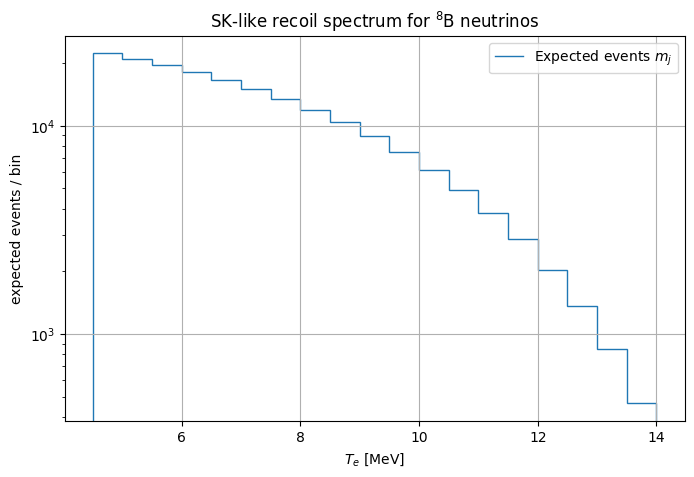

In [8]:
fig, ax = plt.subplots()

ax.stairs(m, edges, label=r"Expected events $m_j$")
ax.set_yscale("log")
ax.set_xlabel(r"$T_e$ [MeV]")
ax.set_ylabel("expected events / bin")
ax.set_title(r"SK-like recoil spectrum for $^8\mathrm{B}$ neutrinos")
ax.legend()

plt.show()

In [9]:
event_table = pd.DataFrame({
    "T_low_MeV": edges[:-1],
    "T_high_MeV": edges[1:],
    "T_center_MeV": centers,
    "expected_events": m,
})

display(event_table.head())
print(f"Total expected events above {template['Tmin']:.1f} MeV = {m.sum():.3f}")

,T_low_MeV,T_high_MeV,T_center_MeV,expected_events
0,4.5,5.0,4.75,22174.578056
1,5.0,5.5,5.25,20898.293926
2,5.5,6.0,5.75,19528.653010
3,6.0,6.5,6.25,18080.902403
4,6.5,7.0,6.75,16572.947595


Total expected events above 4.5 MeV = 186693.543


## 7. Generate pseudo-data

We choose a true normalization

$$
\alpha_B^{\rm true}=1
$$

and generate Poisson-distributed counts:

$$
n_j\sim\mathrm{Poisson}(\alpha_B^{\rm true}m_j).
$$


In [11]:
rng = np.random.default_rng(12345)

alpha_true = 1.0
n = rng.poisson(alpha_true * m)

print(f"sum expected = {m.sum():.3f}")
print(f"sum pseudo-data = {n.sum()}")

sum expected = 186693.543
sum pseudo-data = 186665


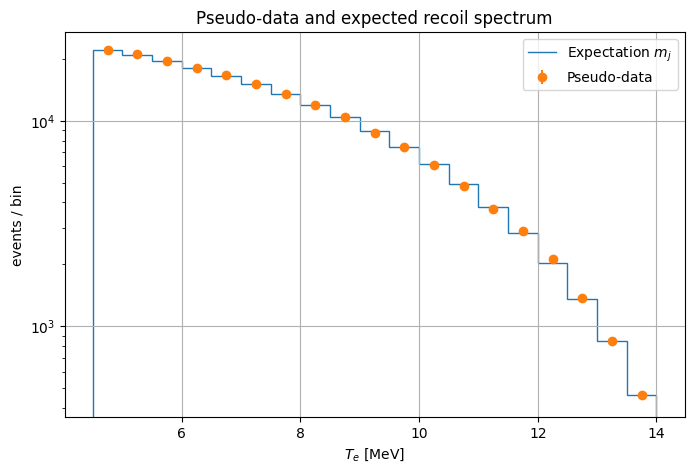

In [12]:
fig, ax = plt.subplots()

ax.stairs(m, edges, label=r"Expectation $m_j$")
ax.errorbar(
    centers,
    n,
    yerr=np.sqrt(np.maximum(n, 1)),
    fmt="o",
    label="Pseudo-data",
)

ax.set_yscale("log")
ax.set_xlabel(r"$T_e$ [MeV]")
ax.set_ylabel("events / bin")
ax.set_title("Pseudo-data and expected recoil spectrum")
ax.legend()

plt.show()

## 8. One-parameter fit of $\alpha_B$

The model is

$$
\mu_j(\alpha_B)=\alpha_Bm_j.
$$

For Poisson bins,

$$
\ell(\alpha_B)
=
\sum_j
\left[
n_j\ln\mu_j(\alpha_B)-\mu_j(\alpha_B)
\right]
+\mathrm{const}.
$$

We define

$$
q(\alpha_B)
=
-2\left[
\ell(\alpha_B)-\ell(\hat\alpha_B)
\right].
$$

For one fitted parameter, the usual approximate $1\sigma$ interval is

$$
q(\alpha_B)\le1.
$$


In [13]:
alphas = np.linspace(0.98, 1.02, 401)

mu = alphas[:, None] * m[None, :]
mu = np.maximum(mu, 1e-300)

ll = np.sum(n[None, :] * np.log(mu) - mu, axis=1)
q = -2.0 * (ll - ll.max())

alpha_hat = alphas[np.argmax(ll)]

inside = alphas[q <= 1.0]
alpha_left = inside[0]
alpha_right = inside[-1]

print(f"alpha_hat = {alpha_hat:.6f}")
print(f"q <= 1 interval: {alpha_left:.6f} ... {alpha_right:.6f}")

alpha_hat = 0.999800
q <= 1 interval: 0.997600 ... 1.002100


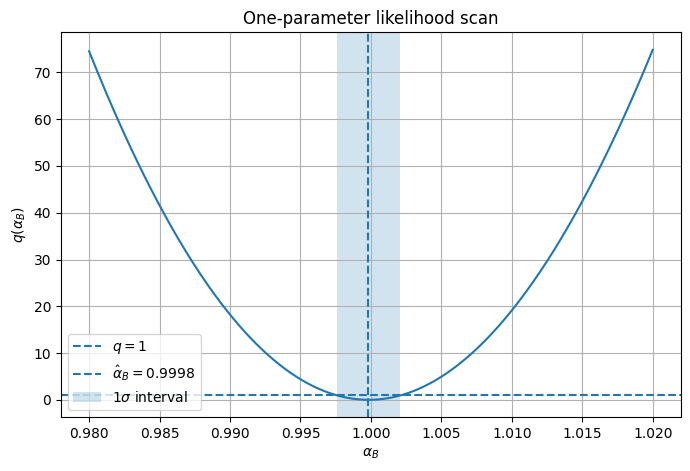

In [14]:
fig, ax = plt.subplots()

ax.plot(alphas, q)
ax.axhline(1.0, linestyle="--", label=r"$q=1$")
ax.axvline(alpha_hat, linestyle="--", label=fr"$\hat\alpha_B={alpha_hat:.4f}$")
ax.axvspan(alpha_left, alpha_right, alpha=0.2, label=r"$1\sigma$ interval")

ax.set_xlabel(r"$\alpha_B$")
ax.set_ylabel(r"$q(\alpha_B)$")
ax.set_title(r"One-parameter likelihood scan")
ax.legend()

plt.show()

## 9. Analytic check

Because the model is linear,

$$
\mu_j(\alpha_B)=\alpha_B m_j,
$$

the maximum-likelihood estimator is

$$
\hat\alpha_B
=
\frac{\sum_j n_j}{\sum_j m_j}.
$$

This is a useful check of the grid fit.


In [15]:
alpha_hat_check = n.sum() / m.sum()

print(f"grid alpha_hat     = {alpha_hat:.6f}")
print(f"analytic alpha_hat = {alpha_hat_check:.6f}")
print(f"difference         = {alpha_hat - alpha_hat_check:.6e}")

grid alpha_hat     = 0.999800
analytic alpha_hat = 0.999847
difference         = -4.711447e-05


## 10. Final summary

This notebook produced:

- normalized ${}^8\mathrm{B}$ spectrum;
- differential ${}^8\mathrm{B}$ flux;
- SK-like recoil-electron event template $m_j$;
- total expected events above a chosen threshold;
- pseudo-data $n_j$ in the same bins;
- best-fit $\hat\alpha_B$;
- one-dimensional interval from $q(\alpha_B)$;
- analytic check of the fitted normalization.


## 11. Different thresholds